# Showcase of the processing pipeline from image to rheology

In [1]:
%load_ext autoreload
%autoreload 2
import sys
import os
from pathlib import Path
sys.path.append(str(Path(os.getcwd()).parent))

from Cilia import ParticleTracker

In [2]:
FILEDIR = str(Path.cwd().parent / 'data/measurement/')
FPS = 200

## Initiate Object and process images

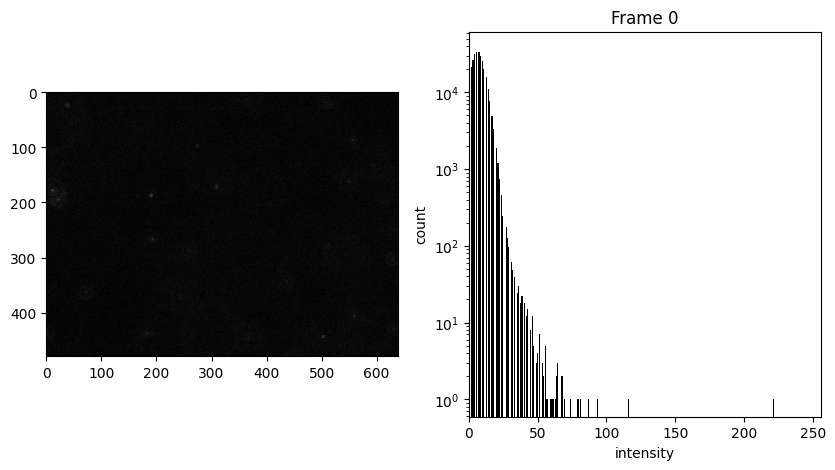

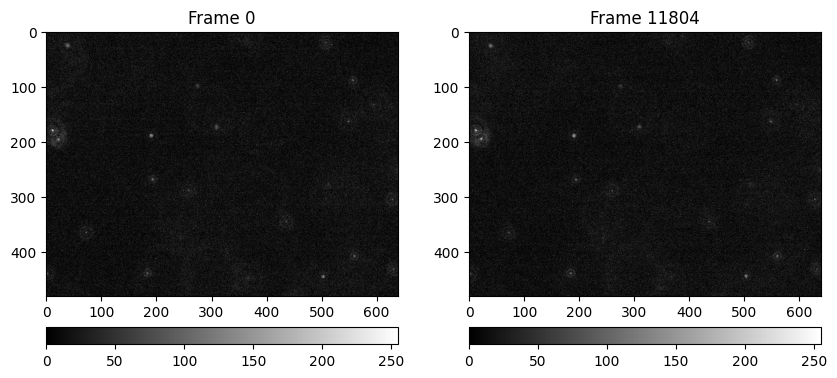

In [3]:
SixtySec = ParticleTracker().load(FILEDIR, '200FPS_60sec.tif', fps=200).show_frame_intensity(0).intensity_clipping(0, 100).scale_full().show_frame([0,-1])

## Check if location algorithm works with given parameters

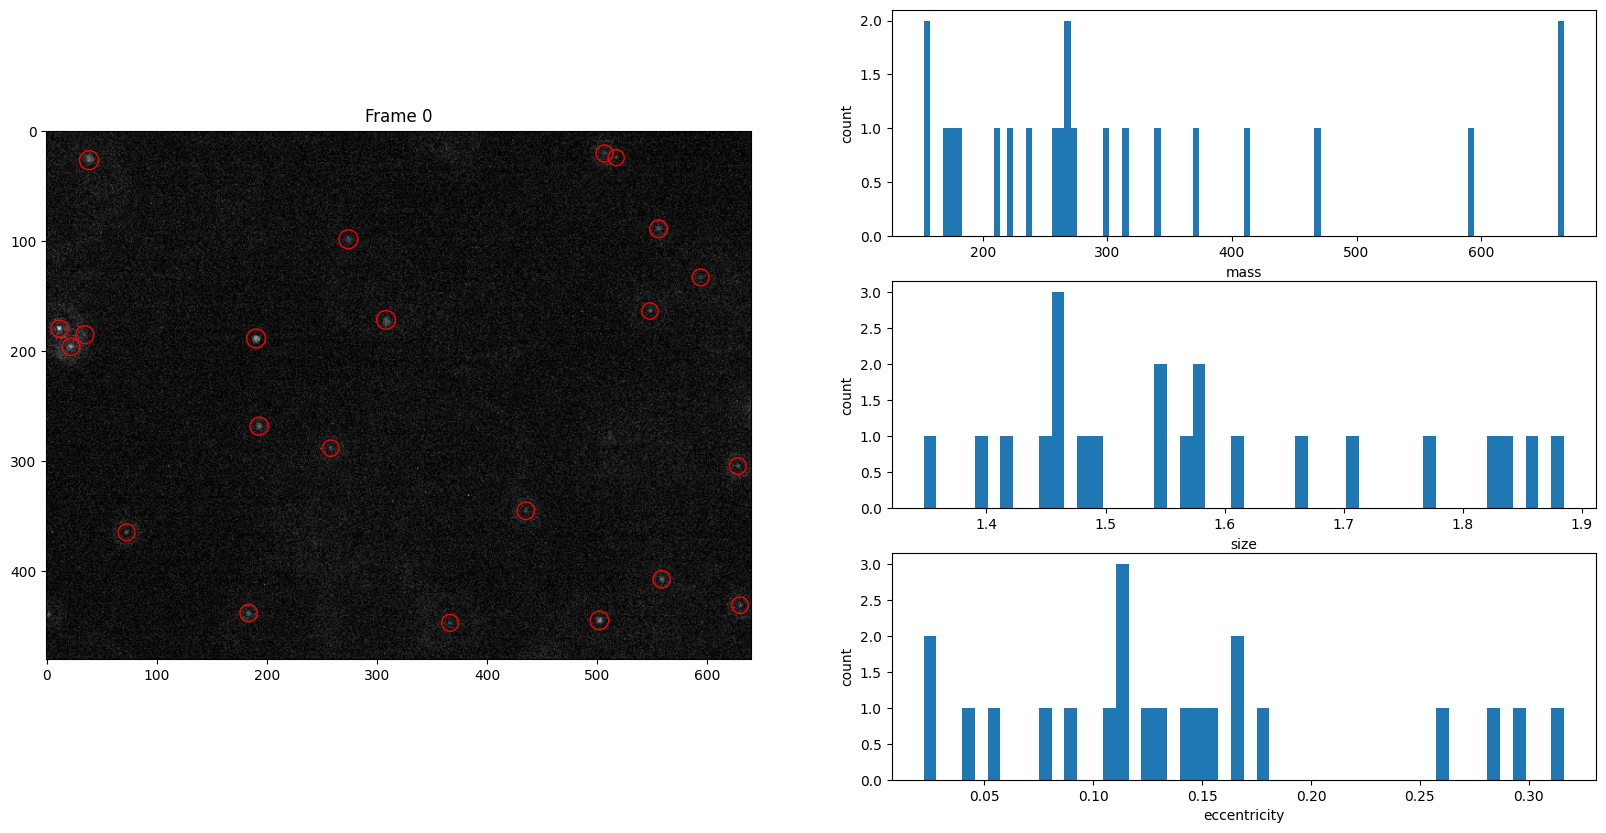

In [4]:
tp_locate_kwargs = {'diameter':7, 'minmass':150, 'maxsize':3}
tp_link_kwargs = {'search_range': 5, 'memory': 2}

treshold = 30
SixtySec.locate_in_frame(0, tp_locate_kwargs, show=True)

## Locate particles in all frames, assemble into trajectories and calculate the MSD

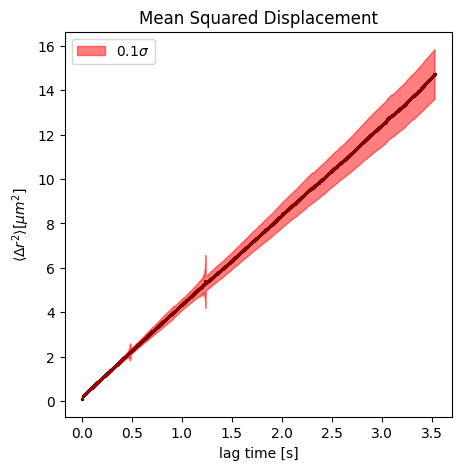

In [5]:
SixtySec.assemble_tracks(tp_locate_kwargs, tp_link_kwargs, treshold, show=False).subtract_drift(show=False)
tp_emsd_kwargs = {'mpp': 0.174, 'max_lagtime': len(SixtySec)}
SixtySec.calculate_msd(tp_emsd_kwargs=tp_emsd_kwargs, percentile=80, show=True)

## Calculate the rheological properties

In [6]:
SixtySec.calculate_moduli(temperature=273.15+25, radius=250e-9, modus='viscous', show=True)

Viscous Modulus: 0.8566616694919553 mPa*s


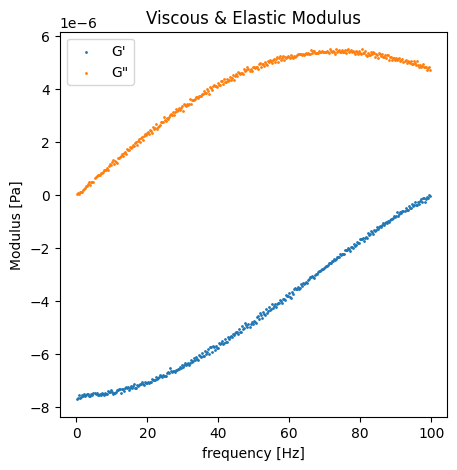

In [7]:
SixtySec.calculate_moduli(temperature=273.15+25, radius=250e-9, modus='viscoelastic', show=True)